In [1]:
import requests, re, time
import pandas as pd
from bs4 import BeautifulSoup

rating_map = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}

def scrape_books(pages=50):
    rows = []
    for p in range(1, pages + 1):
        r = requests.get(f"https://books.toscrape.com/catalogue/page-{p}.html")
        soup = BeautifulSoup(r.text, "html.parser")
        for b in soup.select("article.product_pod"):
            rows.append({
                "title": b.h3.a["title"],
                "price": float(re.sub(r"[^\d.]", "", b.select_one("p.price_color").text)),
                "rating": rating_map[b.select_one("p.star-rating")["class"][1]],
                "availability": b.select_one("p.availability").text.strip(),
            })
        time.sleep(0.3)
    return pd.DataFrame(rows)

books = scrape_books()
print(books.shape)
books.head()

(1000, 4)


,title,price,rating,availability
0,A Light in the Attic,51.77,3,In stock
1,Tipping the Velvet,53.74,1,In stock
2,Soumission,50.10,1,In stock
3,Sharp Objects,47.82,4,In stock
4,Sapiens: A Brief History of Humankind,54.23,5,In stock


In [2]:
books = books.drop_duplicates().dropna()
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1000 non-null   object 
 1   price         1000 non-null   float64
 2   rating        1000 non-null   int64  
 3   availability  1000 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 31.4+ KB


In [3]:
print(books.describe())
print(books.groupby("rating")["price"].mean().round(2))
print(books.sort_values("price", ascending=False).head(5)[["title", "price", "rating"]])
print(books[["price", "rating"]].corr())

            price       rating
count  1000.00000  1000.000000
mean     35.07035     2.923000
std      14.44669     1.434967
min      10.00000     1.000000
25%      22.10750     2.000000
50%      35.98000     3.000000
75%      47.45750     4.000000
max      59.99000     5.000000
rating
1    34.56
2    34.81
3    34.69
4    36.09
5    35.37
Name: price, dtype: float64
                                  title  price  rating
648  The Perfect Play (Play by Play #1)  59.99       3
617   Last One Home (New Beginnings #1)  59.98       3
860    Civilization and Its Discontents  59.95       2
560      The Barefoot Contessa Cookbook  59.92       5
366           The Diary of a Young Girl  59.90       3
           price    rating
price   1.000000  0.028166
rating  0.028166  1.000000


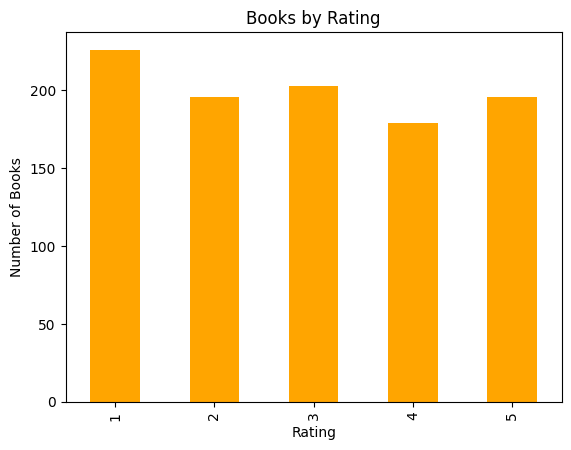

In [4]:
import matplotlib.pyplot as plt
books["rating"].value_counts().sort_index().plot(kind="bar", color="orange", title="Books by Rating")
plt.xlabel("Rating"); plt.ylabel("Number of Books"); plt.show()

In [5]:
books.to_csv("books_data.csv", index=False)
books.to_excel("books_data.xlsx", index=False)

Task 5: Web Data Extraction & Analysis
- Scraped 1000 books from books.toscrape.com using Requests and BeautifulSoup.
- Extracted title, price, rating and availability, then cleaned and structured the data.
- Prices vary widely, and price shows almost no relationship with rating.
- Automated the scraping in a function and exported results to CSV and Excel.